In [23]:
import pandas as pd
from stabl.multi_omic_pipelines import multi_omic_stabl
from stabl.multi_omic_pipelines import multi_omic_stabl_cv
import numpy as np
from sklearn.linear_model import Lasso, ElasticNet, LogisticRegression
from sklearn.model_selection import GridSearchCV
from stabl.stabl import Stabl
from stabl.adaptive import ALasso

X_proteo = pd.read_csv(f"../InitialDataExploration/data/COVID-19/Training/Proteomics.csv",index_col=0)
y =  pd.read_csv(f"../InitialDataExploration/data/COVID-19/Training/Mild&ModVsSevere.csv",index_col=0).iloc[:,0]

X_proteo_test = pd.read_csv(f"../InitialDataExploration/data/COVID-19/Validation/Validation_proteomics.csv",index_col=0)

X_test = {
    "Proteomics": X_proteo_test,
}
y_test = pd.read_csv(f"../InitialDataExploration/data/COVID-19/Validation/Validation_outcome(WHO.0 >= 5).csv",index_col=0).iloc[:,0]

# Alignement : si y_test est inversé par rapport à y, on corrige
y = y.astype(int)
y_test = 1 - y_test.astype(int)

data_dict = {
    "Proteomics": X_proteo,
}

"yo"

stabl_lasso = Stabl(
    base_estimator=LogisticRegression(l1_ratio=1.0, solver="saga", tol=1e-2),
    lambda_grid="auto",
    artificial_type="random_permutation",
    n_bootstraps=100,
)
stabl_alasso = Stabl(
      base_estimator=ALasso(tol=1e-3),
      lambda_grid="auto",
      artificial_type="random_permutation",
      n_bootstraps=100,
)

stabl_en = Stabl(
      base_estimator=ElasticNet(l1_ratio=0.5, tol=1e-3),
      lambda_grid="auto",
      artificial_type="random_permutation",
      n_bootstraps=100,
)

In [24]:
import warnings
from sklearn.exceptions import ConvergenceWarning                                                                                                                 
warnings.filterwarnings("ignore", category=ConvergenceWarning) 

from stabl.adaptive import ALogitLasso
C_grid = np.logspace(-2, 0, 10)

lasso_cv = GridSearchCV(
    LogisticRegression(l1_ratio=1.0, solver="liblinear", class_weight="balanced", max_iter=1000000),
    param_grid={"C": C_grid},
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

alasso_cv = GridSearchCV(
      ALogitLasso(),
      param_grid={"C": C_grid},
      cv=5, scoring="roc_auc", n_jobs=-1
  )

en_cv = GridSearchCV(
    LogisticRegression(l1_ratio=0.5, solver="saga", class_weight="balanced", max_iter=int(1e6)),
    param_grid={"C": C_grid},
    cv=5, scoring="roc_auc", n_jobs=-1
)

estimators = {
    "lasso": lasso_cv,
    "alasso": alasso_cv,
    "en": en_cv,
    "stabl_lasso": stabl_lasso,
    "stabl_alasso": stabl_alasso,
    "stabl_en": stabl_en,
}

models = ["STABL Lasso", "STABL ALasso", "STABL ElasticNet", "Lasso", "ALasso", "ElasticNet"]

predictions_dict = multi_omic_stabl(
    data_dict=data_dict,
    y=y,
    estimators=estimators,
    task_type="binary",
    save_path="results",
    models=models,
    stabl_params=None,
    early_fusion=False,
    X_test=X_test,
    y_test=y_test,
    n_iter_lf=10000
)

Fitting of STABL Lasso on Proteomics
STABL Lasso finished on Proteomics (68 samples); 195 features selected
Fitting of STABL ALasso on Proteomics
STABL ALasso finished on Proteomics (68 samples); 12 features selected
Fitting of STABL ElasticNet on Proteomics
STABL ElasticNet finished on Proteomics (68 samples); 3 features selected
Fitting of Lasso on Proteomics
Lasso finished on Proteomics (68 samples); 14 features selected
Fitting of ALasso on Proteomics
ALasso finished on Proteomics (68 samples); 1 features selected
Fitting of ElasticNet on Proteomics
ElasticNet finished on Proteomics (68 samples); 68 features selected


Late Fusion ElasticNet: 100%|██████████| 3/3 [01:44<00:00, 34.89s/it]


~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
This fold: 195 features selected for STABL Lasso
This fold: 12 features selected for STABL ALasso
This fold: 3 features selected for STABL ElasticNet
This fold: 14 features selected for Lasso
This fold: 1 features selected for ALasso
This fold: 68 features selected for ElasticNet
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~



KeyboardInterrupt: 

In [32]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

scale_pos = (y == 0).sum() / (y == 1).sum()

xgb_cv = GridSearchCV(                                                                                                                                   
    XGBClassifier(
    n_estimators=100,                                                                                                                                
    eval_metric="logloss",                                                                                                                         
    use_label_encoder=False,                                                                                                                       
    random_state=42,
    scale_pos_weight=scale_pos,
    reg_alpha=1.0,
    reg_lambda=5.0,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    max_delta_step=1,
    ),
    param_grid={
        "max_depth": [2, 3, 4],
        "learning_rate": [0.01, 0.05, 0.1],
    },
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
)

svm_cv = GridSearchCV(
    SVC(probability=True, class_weight="balanced", random_state=42),
    param_grid={
        "C": [0.1, 1, 10],
        "kernel": ["rbf", "linear"],
    },
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
)

rf_cv = GridSearchCV(
    RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        bootstrap=True,
        max_samples=0.8,
        max_features="sqrt",
        min_samples_leaf=3,
        min_samples_split=8,
    ),
    param_grid={
        "n_estimators": [200, 500],
        "max_depth": [3, 5, 7, None],
        "min_samples_leaf": [3, 5, 10],
    },
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
)

stabl_xgboost = Stabl(
    base_estimator=XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        scale_pos_weight=scale_pos,
        reg_alpha=1.0,
        reg_lambda=5.0,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
    ),
    lambda_grid={
            "max_depth": [2, 3],
            "learning_rate": [0.05, 0.1, 0.2],
            "n_estimators": [50, 100],
    },
    artificial_type="random_permutation",
    n_bootstraps=50,
)

estimators_enhanced = {
    "lasso": lasso_cv,
    "alasso": alasso_cv,
    "en": en_cv,
    "stabl_lasso": stabl_lasso,
    "stabl_alasso": stabl_alasso,
    "stabl_en": stabl_en,
    "stabl_xgboost": stabl_xgboost,
    "xgboost": xgb_cv,
    "svm": svm_cv,
    "random_forest": rf_cv,
}

predictions_enhanced = multi_omic_stabl(
    data_dict=data_dict,
    y=y,
    estimators=estimators_enhanced,
    task_type="binary_xgboost",
    save_path="results",
    models=["XGBoost", "SVM", "RandomForest", "STABL XGBoost"],
    stabl_params=None,
    early_fusion=False,
    X_test=X_test,
    y_test=y_test,
    n_iter_lf=10000,
)

predictions_dict.update(predictions_enhanced)

Fitting of STABL XGBoost on Proteomics
STABL XGBoost finished on Proteomics (68 samples); 19 features selected
Fitting of XGBoost on Proteomics
XGBoost finished on Proteomics (68 samples); 29 features with non-zero importance
Fitting of SVM on Proteomics
SVM finished on Proteomics (68 samples)
Fitting of RandomForest on Proteomics
RandomForest finished on Proteomics (68 samples); 355 features in top 25% importance


Late Fusion RandomForest: 100%|██████████| 3/3 [01:56<00:00, 38.72s/it]


~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
This fold: 29 features selected for XGBoost
This fold: 0 features selected for SVM
This fold: 355 features selected for RandomForest
This fold: 19 features selected for STABL XGBoost
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

STABL XGBoost SampleID
1_D0       0.000000e+00
1_D3      6.499348e-104
2_D3      9.405100e-309
2_D0      5.822569e-192
3_D0      6.663057e-128
              ...      
384_D0     0.000000e+00
384_D7    2.995052e-246
385_D3    1.421605e-275
385_D0    1.299721e-215
386_D0     0.000000e+00
Name: STABL XGBoost predictions, Length: 784, dtype: float64
XGBoost SampleID
1_D0      0.092676
1_D3      0.092676
2_D3      0.092676
2_D0      0.092676
3_D0      0.147523
            ...   
384_D0    0.106684
384_D7    0.167113
385_D3    0.092676
385_D0    0.092676
386_D0    0.107203
Length: 784, dtype: object
SVM SampleID
1_D0      0.014606
1_D3       0.01931
2_D3      0.017153
2_D0      0.044743
3_D0      0.25

STABL Lasso → 784
STABL ALasso → 784
STABL ElasticNet → 784
Lasso → 784
ALasso → 784
ElasticNet → 784
XGBoost → 784
SVM → 784
RandomForest → 784
STABL XGBoost → 784


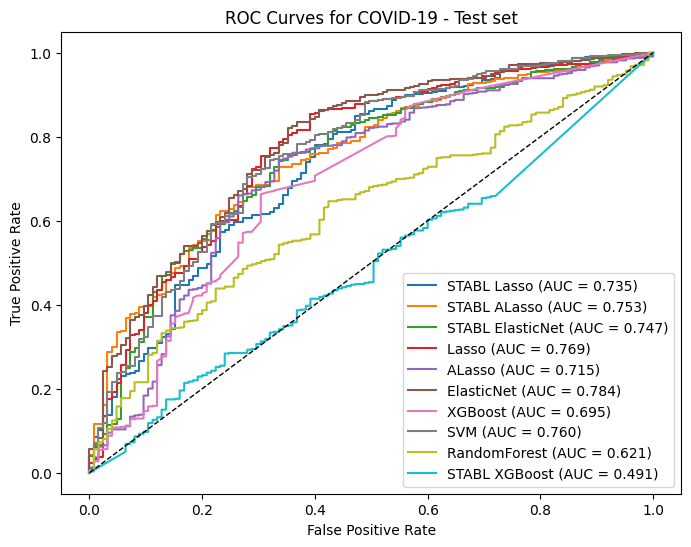

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(8, 6))

for model_name, preds in predictions_dict.items():
    print(model_name, "→", len(preds) if preds is not None else "vide")
    if preds is None or len(preds) == 0:
        continue
    fpr, tpr, _ = roc_curve(y_test, preds)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves for COVID-19 - Test set")
ax.legend(loc="lower right")
plt.show()

In [2]:
import pandas as pd
from stabl.multi_omic_pipelines import multi_omic_stabl
from stabl.multi_omic_pipelines import multi_omic_stabl_cv
import numpy as np
from sklearn.linear_model import Lasso, ElasticNet, LogisticRegression
from sklearn.model_selection import GridSearchCV
from stabl.stabl import Stabl
from stabl.adaptive import ALasso
import warnings
from sklearn.exceptions import ConvergenceWarning                                                                                                                 
warnings.filterwarnings("ignore", category=ConvergenceWarning) 
from sklearn.model_selection import StratifiedKFold
from stabl.adaptive import ALogitLasso
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn import clone


/Users/osmanrittano/Desktop/Machine Learning/BriceLab/stablVMax/stabl/multi_omic_pipelines.py:5: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [ ]:
X_density = pd.read_csv(f"../Jakob1/data/PerioII_PatientFeature_03052026_IMCdensity.csv",index_col=0)

X_function = pd.read_csv(f"../Jakob1/data/PerioII_PatientFeature_03052026_IMCfunction.csv",index_col=0)

X_neighbor = pd.read_csv(f"../Jakob1/data/PerioII_PatientFeature_03052026_IMCneighbor.csv",index_col=0)

X_shape = pd.read_csv(f"../Jakob1/data/PerioII_PatientFeature_03052026_IMCshape.csv",index_col=0)

In [ ]:
penalization_matrix = pd.read_csv(f"../Jakob1/data/penalization_matrix_perio_imc.csv", index_col=0)

def filter_by_penalization(df, pen_matrix):
    cols_to_keep = []
    for col in df.columns:
        parts = col.split("_")
        cell_type = parts[0]
        marker = parts[-1]
        if cell_type not in pen_matrix.index or marker not in pen_matrix.columns:
            cols_to_keep
            continue
        if pen_matrix.loc[cell_type, marker] != 0:
            cols_to_keep.append(col)
    return df[cols_to_keep]

X_function_pen = filter_by_penalization(X_function, penalization_matrix)

In [5]:
median_densities = 1000000 * X_density.median(axis=0)

threshold = 10

prefixe_above = set(
    "_".join(col.split("_")[:2]) for col in median_densities[median_densities >= threshold].index
)

print(prefixe_above)

def matches_prefix_neighbor(col, prefixes):
    parts = col.split("_")
    start = "_".join(parts[:2])
    end = parts[-1] + "_" + parts[1]
    return start in prefixes and end in prefixes

def matches_prefix_other(col, prefixes):
    parts = col.split("_")
    start = "_".join(parts[:2])
    return start in prefixes

def no_other(df):
    return df[[c for c in df.columns if "other" not in c.lower()]]

X_neighbor_filtered = X_neighbor[[col for col in X_neighbor.columns if matches_prefix_neighbor(col, prefixe_above)]]

X_function_filtered_pen = X_function_pen[[col for col in X_function_pen.columns if matches_prefix_other(col, prefixe_above)]]

X_shape_filtered = X_shape[[col for col in X_shape.columns if matches_prefix_other(col, prefixe_above)]]

# Remove "other" cell type features from all datasets
X_density               = no_other(X_density)
X_neighbor_filtered     = no_other(X_neighbor_filtered)
X_function_filtered_pen = no_other(X_function_filtered_pen)
X_shape_filtered        = no_other(X_shape_filtered)


{'Lymphatics_Epiborder', 'CD4Tmem_Stromacore', 'M1_Epiborder', 'Bloodvessels_Stromaborder', 'Neutrophils_Epicore', 'CD8Tmem_Epiborder', 'Lymphatics_Stromaborder', 'CD8Tnaive_Stromaborder', 'M2_Stromacore', 'CD8Tnaive_Stromacore', 'Bloodvessels_Stromacore', 'CD4Tnaive_Stromacore', 'Neutrophils_Stromaborder', 'M1_Stromacore', 'EpiKi67-_Stromaborder', 'CD4Tmem_Stromaborder', 'M1_Stromaborder', 'LC_Epiborder', 'EpiKi67-_Epicore', 'CD8Tmem_Stromaborder', 'EpiKi67+_Stromaborder', 'EpiKi67+_Epiborder', 'M1_Epicore', 'Fibroblast_Stromaborder', 'cDCs_Stromaborder', 'EpiKi67+_Epicore', 'Fibroblast_Epicore', 'cDCs_Stromacore', 'CD4Tnaive_Stromaborder', 'intMCs_Stromaborder', 'Lymphatics_Stromacore', 'EpiKi67-_Epiborder', 'Neutrophils_Stromacore', 'Neutrophils_Epiborder', 'LC_Epicore', 'Bcells_Stromacore', 'CD4Tnaive_Epiborder', 'nMCs_Epiborder', 'CD4Tmem_Epiborder', 'CD8Tnaive_Epiborder', 'Fibroblast_Stromacore', 'intMCs_Stromacore', 'Fibroblast_Epiborder', 'CD4Tnaive_Epicore'}


In [6]:
def make_y(df):
    return pd.Series(
        [0 if x.startswith("HG") else 1 for x in df.index],
        index=df.index,
        name="outcome"
    )

y = make_y(X_density)

print(y)

Patient
HG01    0
HG02    0
HG03    0
HG04    0
HG05    0
HG06    0
HG07    0
HG08    0
HG09    0
HG10    0
HG11    0
HG12    0
HG13    0
HG14    0
HG15    0
HG16    0
PV01    1
PV03    1
PV05    1
PV07    1
PV09    1
PV10    1
PV13    1
PV14    1
PV16    1
PV24    1
PV25    1
PV26    1
PV27    1
PV28    1
Name: outcome, dtype: int64


In [7]:
data_dict = {
    "Density": X_density,
    "Function": X_function_filtered_pen,
    "Neighbor": X_neighbor_filtered,
    "Shape": X_shape_filtered,
}

stabl_lasso = Stabl(
    base_estimator=LogisticRegression(l1_ratio=1.0, solver="saga", tol=1e-2),
    lambda_grid="auto",
    artificial_type="random_permutation",
    n_bootstraps=100,
)
stabl_alasso = Stabl(
      base_estimator=ALasso(tol=1e-3),
      lambda_grid="auto",
      artificial_type="random_permutation",
      n_bootstraps=100,
)

stabl_en = Stabl(
      base_estimator=ElasticNet(l1_ratio=0.5, tol=1e-3),
      lambda_grid="auto",
      artificial_type="random_permutation",
      n_bootstraps=500,
)

In [8]:
C_grid = np.logspace(-2, 0, 10)

lasso_cv = GridSearchCV(
    LogisticRegression(l1_ratio=1.0, solver="liblinear", class_weight="balanced", max_iter=1000000),
    param_grid={"C": C_grid},
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

alasso_cv = GridSearchCV(
      ALogitLasso(),
      param_grid={"C": C_grid},
      cv=5, scoring="roc_auc", n_jobs=-1
  )

en_cv = GridSearchCV(
    LogisticRegression(l1_ratio=0.5, solver="saga", class_weight="balanced", max_iter=int(1e6)),
    param_grid={"C": C_grid},
    cv=5, scoring="roc_auc", n_jobs=-1
)

estimators = {
    "lasso": lasso_cv,
    "alasso": alasso_cv,
    "en": en_cv,
    "stabl_lasso": stabl_lasso,
    "stabl_alasso": stabl_alasso,
    "stabl_en": stabl_en,
}

models = ["STABL ALasso"]

outter_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

predictions_dict = multi_omic_stabl_cv(
    data_dict=data_dict,
    y=y,
    outer_splitter=outter_splitter,
    estimators=estimators,
    task_type="binary",
    save_path="resultsJakob",
    models=models,
    outer_groups=None,
    early_fusion=False,
    late_fusion=True,
    n_iter_lf=10000
)

24 train samples, 6 test samples:   0%|          | 0/5 [00:00<?, ?it/s]Fitting of STABL ALasso
STABL ALasso finished on Density (24 samples); 2 features selected
Fitting of STABL ALasso
STABL ALasso finished on Function (24 samples); 8 features selected
Fitting of STABL ALasso
STABL ALasso finished on Neighbor (24 samples); 15 features selected
Fitting of STABL ALasso
STABL ALasso finished on Shape (24 samples); 7 features selected


0it [00:00, ?it/s]

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
This fold: 32 features selected for STABL ALasso
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

24 train samples, 6 test samples:  20%|██        | 1/5 [00:33<02:12, 33.22s/it]

Fitting of STABL ALasso
STABL ALasso finished on Density (24 samples); 3 features selected
Fitting of STABL ALasso
STABL ALasso finished on Function (24 samples); 4 features selected
Fitting of STABL ALasso
STABL ALasso finished on Neighbor (24 samples); 7 features selected
Fitting of STABL ALasso
STABL ALasso finished on Shape (24 samples); 7 features selected


0it [00:00, ?it/s]

...

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
This fold: 35 features selected for STABL ALasso
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

24 train samples, 6 test samples:  80%|████████  | 4/5 [01:11<00:15, 15.16s/it]Fitting of STABL ALasso


STABL ALasso finished on Density (24 samples); 3 features selected
Fitting of STABL ALasso
STABL ALasso finished on Function (24 samples); 2 features selected
Fitting of STABL ALasso
STABL ALasso finished on Neighbor (24 samples); 7 features selected
Fitting of STABL ALasso
STABL ALasso finished on Shape (24 samples); 5 features selected


0it [00:00, ?it/s]

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
This fold: 17 features selected for STABL ALasso
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

24 train samples, 6 test samples: 100%|██████████| 5/5 [01:23<00:00, 16.65s/it]
Saving results...


STABL ALasso Patient
HG01    6.328187e-02
HG02    7.394367e-03
HG03    1.028635e-05
HG04    2.262891e-07
HG05    2.224428e-05
HG06    5.876654e-02
HG07    6.425277e-03
HG08    9.998380e-01
HG09    5.381172e-07
HG10    3.125193e-02
HG11    2.479621e-06
HG12    1.492084e-01
HG13    1.556380e-02
HG14    1.050606e-03
HG15    3.577136e-05
HG16    9.529517e-01
PV01    1.000000e+00
PV03    9.999749e-01
PV05    4.921808e-02
PV07    9.999813e-01
PV09    9.999919e-01
PV10    7.194575e-01
PV13    7.096008e-02
PV14    9.999534e-01
PV16    9.999992e-01
PV24    4.798501e-02
PV25    3.437401e-03
PV26    8.071715e-01
PV27    1.998155e-01
PV28    9.989564e-01
dtype: float64


STABL ALasso → 30


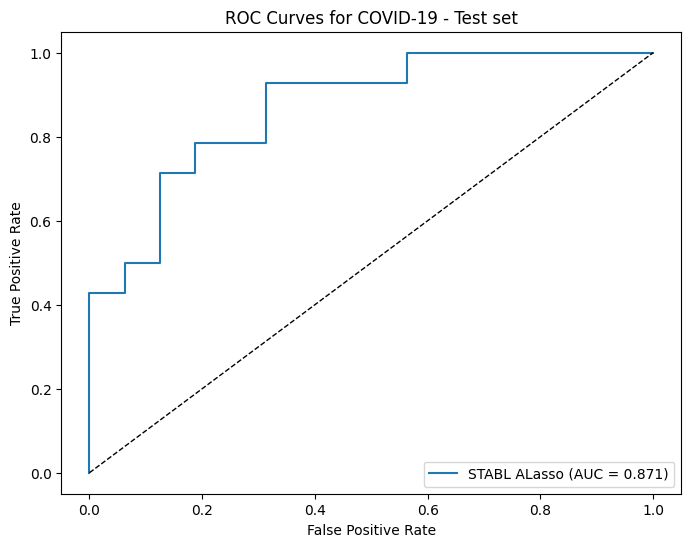

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

for model_name, preds in predictions_dict.items():
    print(model_name, "→", len(preds) if preds is not None else "vide")
    if preds is None or len(preds) == 0:
        continue
    fpr, tpr, _ = roc_curve(y, preds)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves for COVID-19 - Test set")
ax.legend(loc="lower right")
plt.show()

In [10]:
X_shape_filtered_no_ecc = X_shape_filtered[
    [col for col in X_shape_filtered.columns if not col.lower().endswith("eccentricity")]
]


In [11]:
# --- Data dicts: penalized vs unpenalized ---
# Penalized  : density threshold + penalization matrix filter (already computed above)
# Unpenalized: density threshold only (no penalization matrix)


data_dict_penalized = {
    "Density": X_density,
    "Function": X_function_filtered_pen,
    "Neighbor": X_neighbor_filtered,
    "Shape": X_shape_filtered_no_ecc,
}

X_function_filtered = X_function[[col for col in X_function.columns if matches_prefix_other(col, prefixe_above)]]
X_function_filtered = no_other(X_function_filtered)

data_dict_unpenalized = {
    "Density": X_density,
    "Function": X_function_filtered,
    "Neighbor": X_neighbor_filtered,
    "Shape": X_shape_filtered_no_ecc,
}

print("Penalized feature counts:")
for k, v in data_dict_penalized.items():
    print(f"  {k}: {v.shape[1]} features")
print("Unpenalized feature counts:")
for k, v in data_dict_unpenalized.items():
    print(f"  {k}: {v.shape[1]} features")

Penalized feature counts:
  Density: 96 features
  Function: 409 features
  Neighbor: 506 features
  Shape: 88 features
Unpenalized feature counts:
  Density: 96 features
  Function: 748 features
  Neighbor: 506 features
  Shape: 88 features


In [ ]:
def make_stabl_estimators():
    """Returns a fresh estimators dict: knockoff + 1000 bootstraps."""
    return {
        "lasso": clone(lasso_cv),
        "alasso": clone(alasso_cv),
        "en": clone(en_cv),
        "stabl_lasso": Stabl(
            base_estimator=LogisticRegression(l1_ratio=1.0, solver="saga", tol=1e-2,
                                              class_weight="balanced", max_iter=int(1e6)),
            lambda_grid="auto",
            artificial_type="knockoff",
            n_bootstraps=1000,
        ),
        "stabl_alasso": Stabl(
            base_estimator=ALasso(tol=1e-3),
            lambda_grid="auto",
            artificial_type="knockoff",
            n_bootstraps=1000,
        ),
        "stabl_en": Stabl(
            base_estimator=ElasticNet(l1_ratio=0.5, tol=1e-3),
            lambda_grid="auto",
            artificial_type="knockoff",
            n_bootstraps=1000,
        ),
    }

outer_splitter_100 = RepeatedStratifiedKFold(n_splits=5, n_repeats=20, random_state=42)
STABL_MODELS = ["STABL Lasso", "STABL ALasso", "STABL ElasticNet"]

In [ ]:
# ============================================================
# QUICK TEST — paramètres réduits pour tester localement
# Utilise make_stabl_estimators_quick() et outer_splitter_quick
# au lieu de make_stabl_estimators() et outer_splitter_100
# ============================================================

def make_stabl_estimators_quick():
    """50 bootstraps + random_permutation : rapide pour tester localement."""
    return {
        "stabl_lasso": Stabl(
            base_estimator=LogisticRegression(l1_ratio=1.0, solver="saga", tol=1e-2,
                                              class_weight="balanced", max_iter=int(1e6)),
            lambda_grid="auto",
            artificial_type="random_permutation",
            n_bootstraps=50,
        ),
        "stabl_alasso": Stabl(
            base_estimator=ALasso(tol=1e-3),
            lambda_grid="auto",
            artificial_type="random_permutation",
            n_bootstraps=50,
        ),
        "stabl_en": Stabl(
            base_estimator=ElasticNet(l1_ratio=0.5, tol=1e-3),
            lambda_grid="auto",
            artificial_type="random_permutation",
            n_bootstraps=50,
        ),
    }

# 5 folds x 2 repeats = 10 folds au lieu de 100
outer_splitter_quick = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)


In [18]:
import warnings                                                                                                                                                   
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn")                                                                                                         
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn") 
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning, module="sklearn") 
import os                                                                                                                                                         
os.environ["PYTHONWARNINGS"] = "ignore" 

In [22]:
from stabl.sherlock import parse_params
from stabl.EMS import read_json

parse_params("template/params.json")

result_low = read_json(["sbatch", "template/arrayLow.sh"], capture_output=True, text=True)
result_high = read_json(["sbatch", "template/arrayHigh.sh"], capture_output=True, text=True)

print(result_low.stdout, result_low.stderr)
print(result_high.stdout, result_high.stderr)

TypeError: read_json() got an unexpected keyword argument 'capture_output'

In [ ]:
import time, subprocess


In [19]:
# --- Run 1 : Penalized data ---
preds_penalized = multi_omic_stabl_cv(
    data_dict=data_dict_penalized,
    y=y,
    outer_splitter=outer_splitter_100,
    estimators=make_stabl_estimators(),
    task_type="binary",
    save_path="resultsJakob_penalized",
    models=STABL_MODELS.copy(),
    outer_groups=None,
    early_fusion=False,
    late_fusion=False,
    n_iter_lf=10000,
)

24 train samples, 6 test samples:   0%|          | 0/100 [00:00<?, ?it/s]Fitting of STABL Lasso
STABL Lasso finished on Density (24 samples); 3 features selected
Fitting of STABL ALasso
STABL ALasso finished on Density (24 samples); 0 features selected
Fitting of STABL ElasticNet
STABL ElasticNet finished on Density (24 samples); 3 features selected
Fitting of STABL Lasso
24 train samples, 6 test samples:   0%|          | 0/100 [02:21<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
# --- Résultats Run 1 : Penalized ---
from pathlib import Path

auc_path = Path("resultsJakob_penalized/Training CV/auc_progress.csv")
scores_path = Path("resultsJakob_penalized/Summary/Scores training CV.csv")

if auc_path.exists():
    auc_df = pd.read_csv(auc_path)
    print(f"=== AUC cumulatif (penalized) — {len(auc_df)} folds complétés / 100 ===")
    display(auc_df.tail(10))
else:
    print("auc_progress.csv pas encore créé (fold 1 pas encore terminé)")

if scores_path.exists():
    print(" === Scores finaux (penalized) ===")
    display(pd.read_csv(scores_path, index_col=0))
else:
    print("Scores finaux pas encore disponibles (run pas terminé)")


In [ ]:
# --- Run 2 : Unpenalized data ---
preds_unpenalized = multi_omic_stabl_cv(
    data_dict=data_dict_unpenalized,
    y=y,
    outer_splitter=outer_splitter_100,
    estimators=make_stabl_estimators(),
    task_type="binary",
    save_path="resultsJakob_unpenalized",
    models=STABL_MODELS.copy(),
    outer_groups=None,
    early_fusion=False,
    late_fusion=False,
    n_iter_lf=10000,
)

In [ ]:
# --- Résultats Run 2 : Unpenalized ---
from pathlib import Path

auc_path = Path("resultsJakob_unpenalized/Training CV/auc_progress.csv")
scores_path = Path("resultsJakob_unpenalized/Summary/Scores training CV.csv")

if auc_path.exists():
    auc_df = pd.read_csv(auc_path)
    print(f"=== AUC cumulatif (unpenalized) — {len(auc_df)} folds complétés / 100 ===")
    display(auc_df.tail(10))
else:
    print("auc_progress.csv pas encore créé (fold 1 pas encore terminé)")

if scores_path.exists():
    print("
=== Scores finaux (unpenalized) ===")
    display(pd.read_csv(scores_path, index_col=0))
else:
    print("Scores finaux pas encore disponibles (run pas terminé)")


In [ ]:
# --- Feature set comparison across the 6 models ---
import ast
import itertools
import seaborn as sns
from collections import Counter
from pathlib import Path

def load_selected_features(save_path, model_name):
    """Union of all features selected across folds for a given model."""
    csv_path = Path(save_path, "Training CV", f"Selected Features {model_name}.csv")
    df = pd.read_csv(csv_path, index_col=0)
    all_features = set()
    for fold_list in df["Fold selected features"]:
        all_features.update(ast.literal_eval(fold_list))
    return all_features

def jaccard(set_a, set_b):
    if not set_a and not set_b:
        return 1.0
    return len(set_a & set_b) / len(set_a | set_b)

model_labels = {
    "Pen Lasso":    ("resultsJakob_penalized",   "STABL Lasso"),
    "Pen ALasso":   ("resultsJakob_penalized",   "STABL ALasso"),
    "Pen EN":       ("resultsJakob_penalized",   "STABL ElasticNet"),
    "Unpen Lasso":  ("resultsJakob_unpenalized", "STABL Lasso"),
    "Unpen ALasso": ("resultsJakob_unpenalized", "STABL ALasso"),
    "Unpen EN":     ("resultsJakob_unpenalized", "STABL ElasticNet"),
}

feature_sets = {
    label: load_selected_features(path, model)
    for label, (path, model) in model_labels.items()
}

# Summary
print("Features selected per model:")
for label, feats in feature_sets.items():
    print(f"  {label}: {len(feats)} features")

# Jaccard heatmap
labels = list(feature_sets.keys())
n = len(labels)
jac_matrix = np.zeros((n, n))
for i, j in itertools.product(range(n), range(n)):
    jac_matrix[i, j] = jaccard(feature_sets[labels[i]], feature_sets[labels[j]])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    jac_matrix,
    xticklabels=labels, yticklabels=labels,
    annot=True, fmt=".2f",
    cmap="YlOrRd", vmin=0, vmax=1, ax=ax
)
ax.set_title("Jaccard similarity of selected feature sets across 6 STABL models")
plt.tight_layout()
plt.savefig("resultsJakob_feature_comparison.png", dpi=150)
plt.show()

# Features common to ALL 6 models
common_all = set.intersection(*feature_sets.values())
print(f"\nFeatures common to ALL 6 models ({len(common_all)}):")
for f in sorted(common_all):
    print(f"  {f}")

# Features selected by ≥ 4/6 models
feat_counts = Counter(f for feats in feature_sets.values() for f in feats)
robust_feats = {f: c for f, c in feat_counts.items() if c >= 4}
print(f"\nFeatures selected by ≥ 4/6 models ({len(robust_feats)}):")
for f, c in sorted(robust_feats.items(), key=lambda x: -x[1]):
    print(f"  {f}: {c}/6 models")